# The first ML2 notebook!
## 27/02

Hello I'm Gustavo and I'm commiting again

In [6]:
import pandas as pd

In [7]:
df = pd.read_csv('attacking.csv')
df.head()

,serial,player_name,club,position,assists,corner_taken,offsides,dribbles,match_played
0,1,Bruno Fernandes,Man. United,Midfielder,7,10,2,7,7
1,2,Vinícius Júnior,Real Madrid,Forward,6,3,4,83,13
2,2,Sané,Bayern,Midfielder,6,3,3,32,10
3,4,Antony,Ajax,Forward,5,3,4,28,7
4,5,Alexander-Arnold,Liverpool,Defender,4,36,0,9,9


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

# select the predictor columns and target
target = 'assists'
features = ['corner_taken', 'offsides', 'dribbles', 'match_played']

X = df[features]
y = df[target]

# split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# instantiate and train a KNN regression model
model = KNeighborsRegressor(n_neighbors=5)
model.fit(X_train, y_train)

# make predictions on the test set
predictions = model.predict(X_test)

# evaluate
print("Mean squared error:", mean_squared_error(y_test, predictions))
print("R^2 score:", r2_score(y_test, predictions))

# example of a new prediction
example = pd.DataFrame([{
    'corner_taken': 5,
    'offsides': 2,
    'dribbles': 10,
    'match_played': 8
}])
pred_assists = model.predict(example)
print("Predicted assists for example player:", pred_assists[0])

Mean squared error: 0.7166666666666667
R^2 score: -0.05067873303167425
Predicted assists for example player: 1.4


c:\Users\Asus\anaconda3\envs\ML1\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


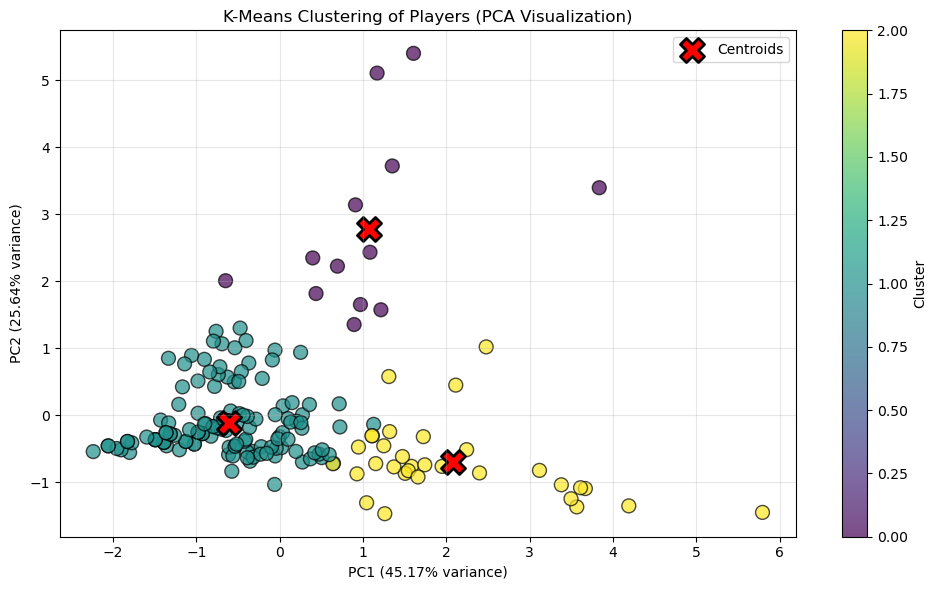

Cluster distribution:
cluster
0     13
1    131
2     32
Name: count, dtype: int64


In [6]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# standardize the features for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# apply k-means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# add cluster labels to dataframe
df['cluster'] = clusters

# use PCA to reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# visualize the clusters
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', 
                     s=100, alpha=0.7, edgecolors='k')
plt.scatter(pca.transform(kmeans.cluster_centers_)[:, 0], 
           pca.transform(kmeans.cluster_centers_)[:, 1],
           c='red', marker='X', s=300, edgecolors='black', linewidths=2,
           label='Centroids')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('K-Means Clustering of Players (PCA Visualization)')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Cluster distribution:\n{df['cluster'].value_counts().sort_index()}")